# Electrostatic Potential of a Peptide from MBIS Atomic Multipoles

This notebook demonstrates the FFprime multipole electrostatics workflow on
a peptide structure:

1. Load the peptide structure and derive **MBIS** (Minimal Basis Iterative
   Stockholder) atomic multipoles.
2. Build monopole, monopole + dipole, and monopole + dipole + quadrupole
   models of the molecular charge density.
3. Validate each model against the exact ESP reference points supplied in
   `peptide-esp.npz`, using quantitative error metrics at each level of
   the expansion.
4. Visualize the spatial potential progression separately, on a regular
   generated grid.
5. Visualize the signed validation error using the irregular NPZ reference
   points.

**MBIS** partitions a molecule's electron density into atomic contributions
using an information-theoretic (iterative stockholder) scheme, producing
well-behaved atomic charges, dipoles, and quadrupoles that reproduce the
molecular electrostatic potential more accurately than charges alone.

A **multipole expansion** represents each atom's local charge distribution
as a series of terms of increasing angular resolution — monopole (net
charge), dipole (charge asymmetry), and quadrupole (charge anisotropy).
Including higher-order terms captures directional electrostatic effects
(e.g. lone pairs, pi systems, backbone amide groups) that a monopole-only
model cannot.

**Important:** the quantitative ESP validation below uses the exact
evaluation points stored in `peptide-esp.npz` (`2.5vdw_points`), NOT a
newly generated grid. A separate 300x300 grid is built later purely to
visualize the spatial structure of the potential and its error, and it
never overwrites the reference points.

Two concepts are kept strictly separate throughout this notebook:

- **NPZ reference points (`reference_points`)** — the exact, irregular 3D
  points supplied in `peptide-esp.npz`, used for all quantitative ESP
  validation (metrics table, error values).
- **Generated grid (`grid_points`)** — a regular 300x300 grid built purely
  for smooth spatial visualization; never used for validation.

## Load Reference NPZ Data

Load the reference ESP dataset. `2.5vdw_points` and `2.5vdw_esp` are the
exact coordinates (in Bohr) and corresponding reference electrostatic
potential values at which the FFprime multipole ESP must be evaluated for
validation. These are kept in their own `reference_*` variables for the
entire notebook so they are never accidentally overwritten by the later
visualization grid.

In [1]:
import numpy as np

npz = np.load("peptide-esp.npz")

print(npz.files)

['fn', 'atnums', 'atcoords', 'vdw_ntheta', 'vdw_scales', '1.5vdw_points', '1.5vdw_esp', '1.5vdw_density', '2.0vdw_points', '2.0vdw_esp', '2.0vdw_density', '2.5vdw_points', '2.5vdw_esp', '2.5vdw_density', '3.0vdw_points', '3.0vdw_esp', '3.0vdw_density', '4.0vdw_points', '4.0vdw_esp', '4.0vdw_density', '5.0vdw_points', '5.0vdw_esp', '5.0vdw_density']


In [2]:
reference_points = npz["2.5vdw_points"]
reference_esp = npz["2.5vdw_esp"]

if len(reference_points) != len(reference_esp):
    raise ValueError(
        "Mismatch between number of reference points and reference ESP "
        f"values: {len(reference_points)} points vs {len(reference_esp)} "
        "ESP values. The reference NPZ data is inconsistent."
    )

## Inspect Reference Points and ESP

In [3]:
print("=" * 40)
print("Reference ESP Data (peptide-esp.npz)")
print("=" * 40)
print(f"Number of reference points : {len(reference_points)}")
print(f"Reference points shape     : {reference_points.shape}")
print(f"Reference ESP shape        : {reference_esp.shape}")

Reference ESP Data (peptide-esp.npz)
Number of reference points : 742
Reference points shape     : (742, 3)
Reference ESP shape        : (742,)


In [4]:
print(reference_points[:5])
print(reference_esp[:5])

[[103.89270929  32.6293636   -0.8099199 ]
 [103.43398433  33.68545437  -0.8099199 ]
 [105.23221852  31.48867303  -1.70307231]
 [105.11398203  32.61361815  -1.70307231]
 [104.76444004  33.68939778  -1.70307231]]
[-0.01495328 -0.01469676 -0.01048346 -0.00991055 -0.00966692]


## Imports

In [5]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Allow importing the local ffprime package when running this notebook
# directly from the examples/ directory.
sys.path.insert(0, str(Path.cwd().parent))

from ffprime.nb import Nonbonded
from ffprime.electrostatics.cartesian import total_potential

## Configuration

All tunable parameters for the evaluation grid and the visualization are
collected here, rather than hardcoded inline, so the example is easy to
adapt to other molecules.

In [6]:
# --- Input structure -------------------------------------------------------
STRUCTURE_FILE = "peptide.fchk"
MBIS_ARGS = "fine"

# --- Visualization grid (NOT used for reference ESP validation) ------------
GRID_POINTS = 300  # points per axis in the evaluation plane
MARGIN = 2.0        # padding (Bohr) added around the molecule's extent

# --- Visualization: color clipping ------------------------------------------
# Multipole potentials diverge close to the nuclei, so the color scale is
# clipped to a physically informative range rather than the raw data range.
# The SAME clip is used for all three progression panels (monopole,
# monopole+dipole, monopole+dipole+quadrupole) so they are directly
# comparable to each other.
POTENTIAL_CLIP = 2.0

# --- Visualization: appearance ------------------------------------------
ATOM_MARKER_SIZE = 110
ATOM_EDGE_WIDTH = 1.2
CONTOUR_LINE_ALPHA = 0.3
CONTOUR_LINE_WIDTH = 0.2
FIGURE_DPI = 300
OUTPUT_FIGURE_VALIDATION = "peptide_esp_validation.png"
OUTPUT_FIGURE_PROGRESSION = "peptide_multipole_progression.png"
OUTPUT_FIGURE_ERROR = "peptide_multipole_error.png"

# Element-based atom coloring (fallback to gray for unlisted elements)
ELEMENT_COLORS = {
    1: "white",      # H
    6: "dimgray",    # C
    7: "royalblue",  # N
    8: "red",        # O
}

## Load Molecule

Load the peptide structure and compute MBIS atomic multipoles
(charges, dipoles, quadrupoles) in a single call.

In [7]:
nb = Nonbonded.from_file(
    STRUCTURE_FILE,
    schemes=["mbis"],
    args=MBIS_ARGS,
)

LOAD peptide.fchk, LOT=None
PREPARE molecule (12 atoms)


c:\Users\ranja\miniconda3\envs\env_qcdevs\lib\site-packages\grid\atomgrid.py:895: UserWarning: Lebedev weights are negative which can introduce round-off errors.
  sphere_grid = AngularGrid(degree=deg_i, method=method)


PART MBIS ...
Building local grids
Integral of density: 40.000304584947834
Optimization
#Iter  #Call         ekld          kld  -constraint     grad.rms  cputime (s)
-----  -----  -----------  -----------  -----------  -----------  -----------
    1      1    1.3144532    1.3147578  -3.0458e-04   1.9792e-01    0.0625000
    2      2    0.8137006    0.3658150   4.4789e-01   1.0297e-01    0.0312500
    3      3    0.8825129   -0.8967302   1.7792e+00   2.2966e-01    0.0312500
    4      4    0.5797553   -1.1129467   1.6927e+00   7.7750e-02    0.0312500
    5      5    0.5582083   -1.0703005   1.6285e+00   6.7729e-02    0.0312500
    6      5    0.5582083   -1.0703005   1.6285e+00   6.7729e-02    0.0312500
    7      6    0.4553857   -0.3123853   7.6777e-01   3.8603e-02    0.0468750
    8      7    0.4117605    0.4112758   4.8469e-04   1.4730e-02    0.0312500
    9      8    0.4102579    0.3659374   4.4320e-02   1.5453e-02    0.0468750
   10      9    0.4029096    0.3384188   6.4491e-02   

## Compute MBIS Multipoles

A brief summary confirms that atomic charges, dipoles, and quadrupoles were
computed for every atom, and that the total charge is conserved.

In [8]:
print("=" * 40)
print("MBIS Multipole Summary")
print("=" * 40)
print(f"Atoms         : {len(nb.atcoords)}")
print(f"Coordinates   : {nb.atcoords.shape}")
print(f"Charges       : {nb.atcharges.shape}")
print(f"Dipoles       : {nb.atdipoles.shape}")
print(f"Quadrupoles   : {nb.atquadrupoles.shape}")
print(f"Total charge  : {np.sum(nb.atcharges):.6f}")

MBIS Multipole Summary
Atoms         : 12
Coordinates   : (12, 3)
Charges       : (12,)
Dipoles       : (12, 3)
Quadrupoles   : (12, 6)
Total charge  : -0.000305


## Prepare Quadrupole Tensors

`Nonbonded` stores each atom's Cartesian quadrupole in flattened Voigt-like
order `(xx, xy, xz, yy, yz, zz)`. The potential/field evaluation routines in
`ffprime.electrostatics.cartesian`, however, operate on the full symmetric
3x3 tensor so that the quadrupole-potential contraction can be expressed
directly as a matrix operation. The helper below performs that conversion
without altering any values.

In [9]:
def quadrupoles_flat_to_tensor(flat: np.ndarray) -> np.ndarray:
    """Convert flattened Cartesian quadrupoles to symmetric 3x3 tensors.

    Parameters
    ----------
    flat : numpy.ndarray of shape (N, 6)
        Flattened Cartesian quadrupole moments for ``N`` atoms, ordered as
        ``(xx, xy, xz, yy, yz, zz)``.

    Returns
    -------
    numpy.ndarray of shape (N, 3, 3)
        Symmetric Cartesian quadrupole tensors, one per atom.

    Raises
    ------
    ValueError
        If ``flat`` does not have shape ``(N, 6)``.
    """
    flat = np.asarray(flat)

    if flat.ndim != 2 or flat.shape[1] != 6:
        raise ValueError(
            f"Expected an array of shape (N, 6), got {flat.shape}."
        )

    n_atoms = flat.shape[0]
    tensor = np.zeros((n_atoms, 3, 3))

    # Diagonal terms
    tensor[:, 0, 0] = flat[:, 0]  # xx
    tensor[:, 1, 1] = flat[:, 3]  # yy
    tensor[:, 2, 2] = flat[:, 5]  # zz

    # Off-diagonal terms (symmetric)
    tensor[:, 0, 1] = tensor[:, 1, 0] = flat[:, 1]  # xy
    tensor[:, 0, 2] = tensor[:, 2, 0] = flat[:, 2]  # xz
    tensor[:, 1, 2] = tensor[:, 2, 1] = flat[:, 4]  # yz

    return tensor


quad_tensor = quadrupoles_flat_to_tensor(nb.atquadrupoles)
print(f"Quadrupole tensor shape: {quad_tensor.shape}")

Quadrupole tensor shape: (12, 3, 3)


## ESP Validation at Exact NPZ Reference Points

This is the quantitative validation step, evaluated at three successive
levels of the multipole expansion. Each level is computed **at the exact
`reference_points` loaded from `peptide-esp.npz`** — never on the
generated grid — so that each value can be compared directly,
point-for-point, against `reference_esp`:

1. `V_mono_reference` — monopole (atomic charges) only.
2. `V_dipole_reference` — monopole + dipole.
3. `V_quad_reference` — monopole + dipole + quadrupole (the full expansion).

In [10]:
V_mono_reference = total_potential(
    atcoords=nb.atcoords,
    points=reference_points,
    atcharges=nb.atcharges,
)

V_dipole_reference = total_potential(
    atcoords=nb.atcoords,
    points=reference_points,
    atcharges=nb.atcharges,
    dipoles=nb.atdipoles,
)

V_quad_reference = total_potential(
    atcoords=nb.atcoords,
    points=reference_points,
    atcharges=nb.atcharges,
    dipoles=nb.atdipoles,
    quadrupoles=quad_tensor,
)

print(f"V_mono_reference shape   : {V_mono_reference.shape}")
print(f"V_dipole_reference shape : {V_dipole_reference.shape}")
print(f"V_quad_reference shape   : {V_quad_reference.shape}")
print(f"reference_esp shape      : {reference_esp.shape}")

for name, arr in (
    ("V_mono_reference", V_mono_reference),
    ("V_dipole_reference", V_dipole_reference),
    ("V_quad_reference", V_quad_reference),
):
    assert arr.shape == reference_esp.shape, (
        f"{name} was not evaluated at the same points as the reference "
        "ESP; shapes do not match."
    )

V_mono_reference shape   : (742,)
V_dipole_reference shape : (742,)
V_quad_reference shape   : (742,)
reference_esp shape      : (742,)


## Validation Metrics

Standard error metrics comparing each level of the FFprime multipole
expansion against the reference ESP, all evaluated at the identical set of
`reference_points`. This quantifies the progression:
**Monopole → Monopole + Dipole → Monopole + Dipole + Quadrupole**.

In [11]:
def r_squared(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Coefficient of determination (R^2), standard definition.

    R^2 = 1 - SS_res / SS_tot, where SS_res is the residual sum of squares
    and SS_tot is the total sum of squares about the mean of ``y_true``.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot


def compute_esp_metrics(esp_pred: np.ndarray, esp_ref: np.ndarray) -> dict:
    """Compute standard ESP validation metrics and the signed error array."""
    error = esp_pred - esp_ref
    return {
        "error": error,
        "rmse": np.sqrt(np.mean(error**2)),
        "mae": np.mean(np.abs(error)),
        "max_abs": np.max(np.abs(error)),
        "mean_signed": np.mean(error),
        "r2": r_squared(esp_ref, esp_pred),
        "pearson_r": np.corrcoef(esp_ref, esp_pred)[0, 1],
    }


metrics_mono = compute_esp_metrics(V_mono_reference, reference_esp)
metrics_dipole = compute_esp_metrics(V_dipole_reference, reference_esp)
metrics_quad = compute_esp_metrics(V_quad_reference, reference_esp)

# Pull out the per-point signed error arrays used later for the error figure.
error_mono = metrics_mono["error"]
error_dipole = metrics_dipole["error"]
error_quad = metrics_quad["error"]

In [12]:
print("=" * 40)
print("ESP Validation Summary")
print("=" * 40)
print(f"Number of points compared: {len(reference_esp)}\n")

rows = [
    ("Monopole", metrics_mono),
    ("Monopole + Dipole", metrics_dipole),
    ("Monopole + Dipole + Quadrupole", metrics_quad),
]

header = (
    f"| {'Model':<31} | {'RMSE':>10} | {'MAE':>10} "
    f"| {'Max Abs Error':>14} | {'R2':>8} |"
)
separator = (
    "|" + "-" * 33 + "|" + "-" * 12 + "|" + "-" * 12
    + "|" + "-" * 16 + "|" + "-" * 10 + "|"
)

print(header)
print(separator)
for name, m in rows:
    print(
        f"| {name:<31} | {m['rmse']:>10.4e} | {m['mae']:>10.4e} "
        f"| {m['max_abs']:>14.4e} | {m['r2']:>8.4f} |"
    )

print()
print("Additional diagnostics (mean signed error, Pearson r):")
for name, m in rows:
    print(
        f"  {name:<31} mean signed = {m['mean_signed']:>10.4e} a.u., "
        f"pearson r = {m['pearson_r']:.6f}"
    )
print("=" * 40)
print(
    "The table above reports RMSE, MAE, max absolute error, and R^2 for "
    "each model as actually computed against the reference ESP. Whether "
    "adding dipole and/or quadrupole terms improves agreement should be "
    "read directly from these numbers rather than assumed."
)

ESP Validation Summary
Number of points compared: 742

| Model                           |       RMSE |        MAE |  Max Abs Error |       R2 |
|---------------------------------|------------|------------|----------------|----------|
| Monopole                        | 1.1010e-03 | 9.0199e-04 |     2.1622e-03 |   0.9889 |
| Monopole + Dipole               | 3.7668e-04 | 2.7168e-04 |     1.3245e-03 |   0.9987 |
| Monopole + Dipole + Quadrupole  | 1.5384e-04 | 1.2453e-04 |     4.5246e-04 |   0.9998 |

Additional diagnostics (mean signed error, Pearson r):
  Monopole                        mean signed = -9.1959e-05 a.u., pearson r = 0.998477
  Monopole + Dipole               mean signed = -4.0183e-05 a.u., pearson r = 0.999358
  Monopole + Dipole + Quadrupole  mean signed = -3.2923e-05 a.u., pearson r = 0.999897
The table above reports RMSE, MAE, max absolute error, and R^2 for each model as actually computed against the reference ESP. Whether adding dipole and/or quadrupole terms improv

## Reference vs. FFprime Scatter Plot

Direct point-by-point comparison of the reference ESP (x-axis) against each
of the three FFprime models (y-axis), all evaluated at the same
`reference_points`: monopole, monopole + dipole, and monopole + dipole +
quadrupole. Perfect agreement would place every point on the `y = x` line.
Each panel reports the RMSE, MAE, and R^2 for that specific model.

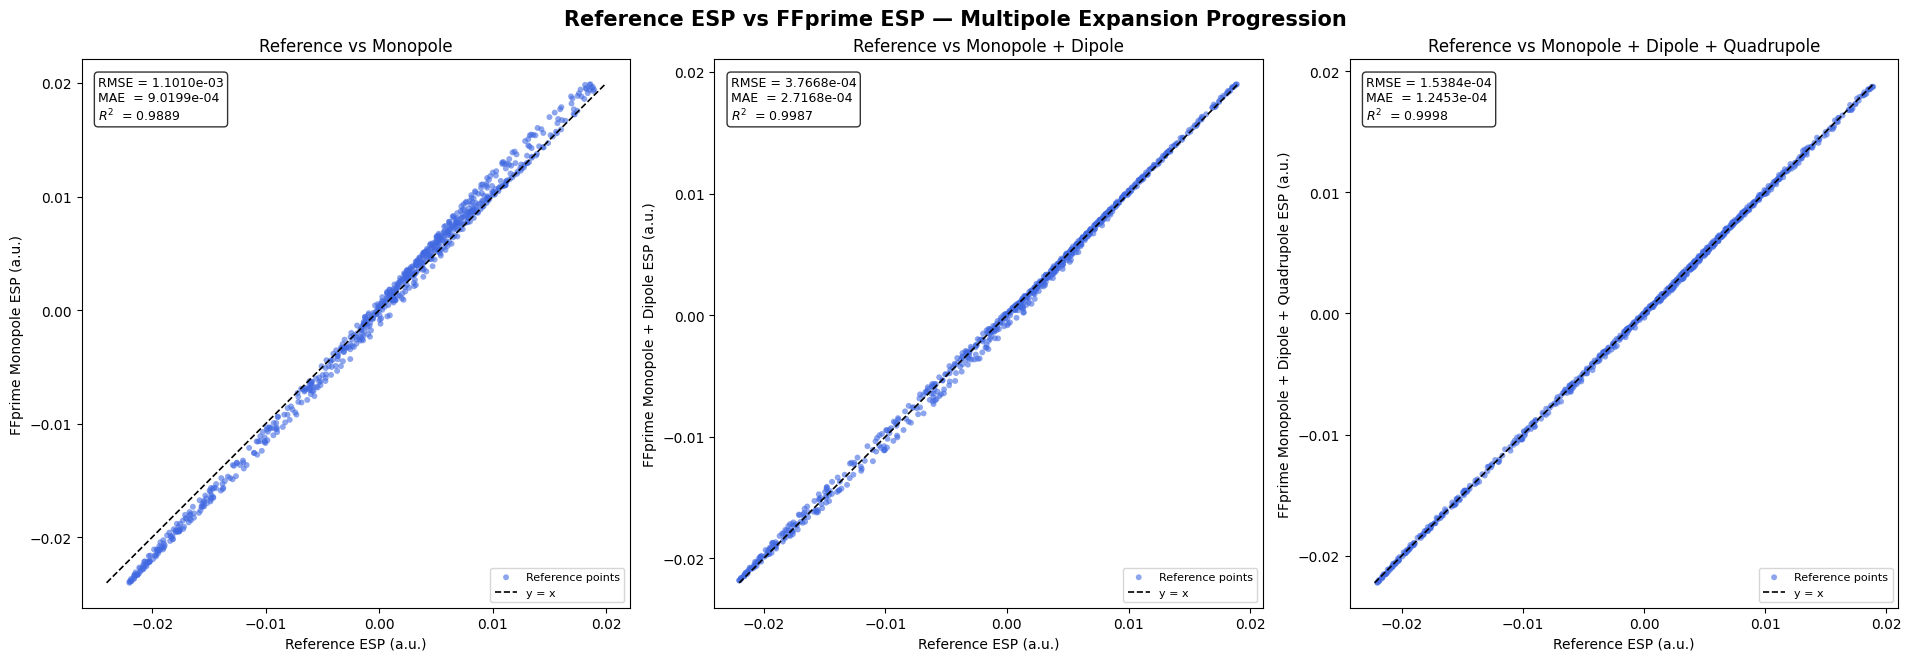

In [13]:
def plot_reference_scatter_panel(ax, esp_pred, metrics, title, ylabel):
    """Draw one reference-vs-FFprime scatter panel with metrics annotated."""
    ax.scatter(
        reference_esp,
        esp_pred,
        s=18,
        alpha=0.6,
        edgecolors="none",
        color="royalblue",
        label="Reference points",
    )

    lo = min(reference_esp.min(), esp_pred.min())
    hi = max(reference_esp.max(), esp_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="y = x")

    ax.set_xlabel("Reference ESP (a.u.)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)

    metrics_text = (
        f"RMSE = {metrics['rmse']:.4e}\n"
        f"MAE  = {metrics['mae']:.4e}\n"
        f"$R^2$  = {metrics['r2']:.4f}"
    )
    ax.text(
        0.03, 0.97, metrics_text,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )


fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), constrained_layout=True)
fig.suptitle(
    "Reference ESP vs FFprime ESP \u2014 Multipole Expansion Progression",
    fontsize=15,
    fontweight="bold",
)

plot_reference_scatter_panel(
    axes[0], V_mono_reference, metrics_mono,
    title="Reference vs Monopole",
    ylabel="FFprime Monopole ESP (a.u.)",
)
plot_reference_scatter_panel(
    axes[1], V_dipole_reference, metrics_dipole,
    title="Reference vs Monopole + Dipole",
    ylabel="FFprime Monopole + Dipole ESP (a.u.)",
)
plot_reference_scatter_panel(
    axes[2], V_quad_reference, metrics_quad,
    title="Reference vs Monopole + Dipole + Quadrupole",
    ylabel="FFprime Monopole + Dipole + Quadrupole ESP (a.u.)",
)

plt.savefig(OUTPUT_FIGURE_VALIDATION, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

## Separate Generated Grid (For Visualization Only)

Everything below builds a smooth 300x300 grid purely to visualize the
spatial structure of the FFprime multipole expansion and its error in the
`z = 0` plane. **This grid is not used for, and is never compared against,
the reference ESP validation above** — it uses its own `grid_points`
variable, which is kept entirely separate from `reference_points`.

The NPZ reference points are irregular 3D points, so the 742 reference-ESP
values are never reshaped into this 2D grid; the grid ESP values below are
computed independently, directly from FFprime, at the regular grid
coordinates.

In [14]:
xmin = nb.atcoords[:, 0].min() - MARGIN
xmax = nb.atcoords[:, 0].max() + MARGIN

ymin = nb.atcoords[:, 1].min() - MARGIN
ymax = nb.atcoords[:, 1].max() + MARGIN

x = np.linspace(xmin, xmax, GRID_POINTS)
y = np.linspace(ymin, ymax, GRID_POINTS)

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)  # evaluation plane: z = 0

grid_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

## Compute Electrostatic Potential on the Visualization Grid

Evaluate the potential at the same three levels of the expansion on
`grid_points`, for visualization only:

- `V_mono_grid` — monopole only.
- `V_dipole_grid` — monopole + dipole.
- `V_quad_grid` — monopole + dipole + quadrupole (the full expansion).

In [15]:
V_mono_grid = total_potential(
    atcoords=nb.atcoords,
    points=grid_points,
    atcharges=nb.atcharges,
)

V_dipole_grid = total_potential(
    atcoords=nb.atcoords,
    points=grid_points,
    atcharges=nb.atcharges,
    dipoles=nb.atdipoles,
)

V_quad_grid = total_potential(
    atcoords=nb.atcoords,
    points=grid_points,
    atcharges=nb.atcharges,
    dipoles=nb.atdipoles,
    quadrupoles=quad_tensor,
)

V_mono_grid = V_mono_grid.reshape(X.shape)
V_dipole_grid = V_dipole_grid.reshape(X.shape)
V_quad_grid = V_quad_grid.reshape(X.shape)

## Figure 1 — Electrostatic Potential of Peptide: Multipole Expansion

A 3-panel figure showing the progression of the FFprime multipole
expansion, evaluated on the smooth visualization grid (not the NPZ
reference points):

- **Panel 1 — Monopole**: potential from atomic point charges only.
- **Panel 2 — Monopole + Dipole**: adding the atomic dipole contribution.
- **Panel 3 — Monopole + Dipole + Quadrupole**: the full multipole
  expansion.

All three panels share the same color scale (`POTENTIAL_CLIP`) so the
progression can be compared directly. Potential values are clipped near
the nuclei (rather than left unbounded) because the point-multipole
potential diverges at short range, which would otherwise saturate the
color scale and hide the structure elsewhere in the plane.

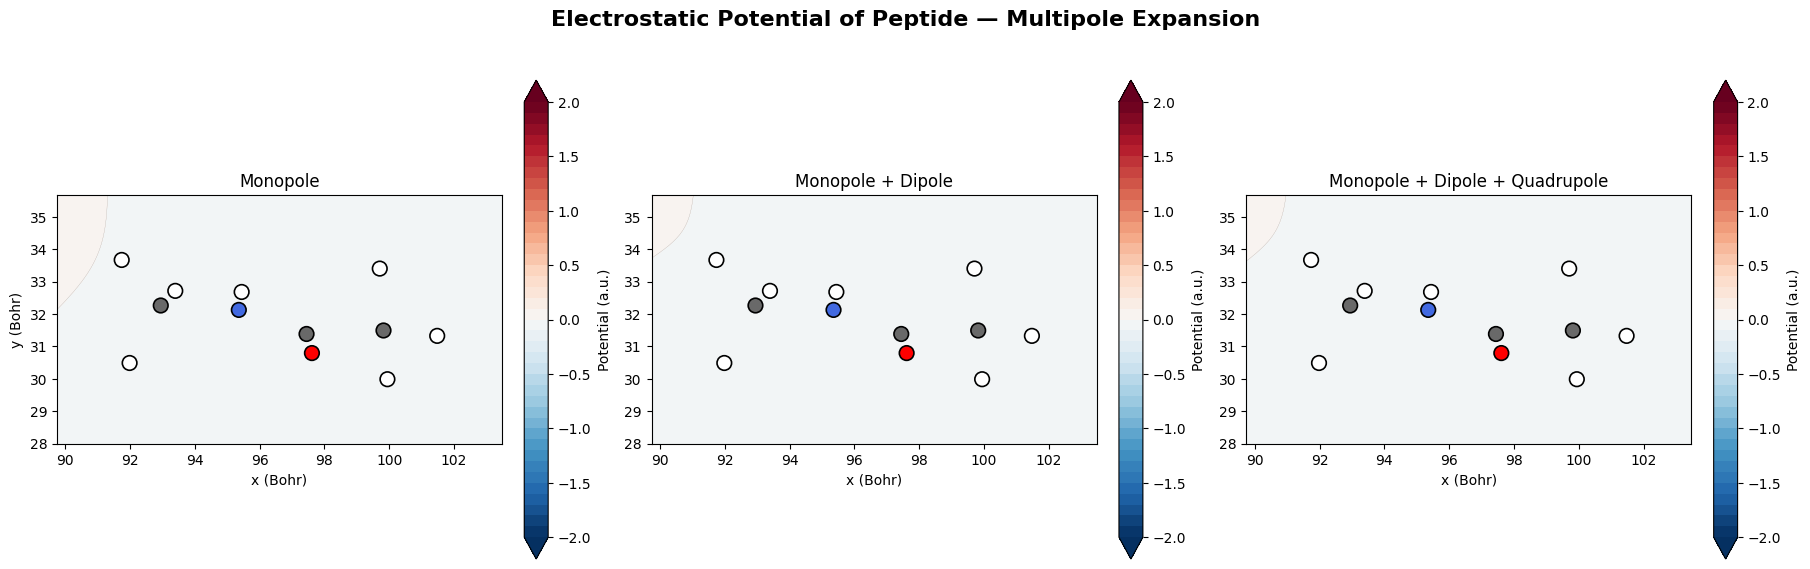

In [16]:
def plot_atoms(ax, atcoords, atnums):
    """Scatter atoms onto an axis using element-based coloring."""
    colors = [ELEMENT_COLORS.get(z, "gray") for z in atnums]
    ax.scatter(
        atcoords[:, 0],
        atcoords[:, 1],
        c=colors,
        edgecolors="black",
        s=ATOM_MARKER_SIZE,
        linewidths=ATOM_EDGE_WIDTH,
        zorder=10,
    )


def plot_potential_panel(
    ax,
    data,
    levels,
    cmap,
    title,
    cbar_label,
    xlabel="x (Bohr)",
    ylabel=None,
):
    """Draw one filled-contour potential panel with atoms overlaid.

    Consolidates the contourf + contour-line + atom-scatter + styling
    logic shared by all panels of the progression figure.
    """
    cf = ax.contourf(X, Y, data, levels=levels, cmap=cmap, extend="both")
    ax.contour(
        X, Y, data,
        levels=levels,
        colors="k",
        linewidths=CONTOUR_LINE_WIDTH,
        alpha=CONTOUR_LINE_ALPHA,
    )
    plot_atoms(ax, nb.atcoords, nb.atnums)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(False)

    plt.colorbar(cf, ax=ax, shrink=0.85, label=cbar_label)


# Clip potentials for visualization (see markdown note above). The SAME clip
# and levels are used for all three panels so they share one color scale.
mono_plot = np.clip(V_mono_grid, -POTENTIAL_CLIP, POTENTIAL_CLIP)
dipole_plot = np.clip(V_dipole_grid, -POTENTIAL_CLIP, POTENTIAL_CLIP)
quad_plot = np.clip(V_quad_grid, -POTENTIAL_CLIP, POTENTIAL_CLIP)

shared_levels = np.linspace(-POTENTIAL_CLIP, POTENTIAL_CLIP, 41)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
fig.suptitle(
    "Electrostatic Potential of Peptide \u2014 Multipole Expansion",
    fontsize=16,
    fontweight="bold",
)

plot_potential_panel(
    axes[0], mono_plot, shared_levels, "RdBu_r",
    title="Monopole",
    cbar_label="Potential (a.u.)",
    ylabel="y (Bohr)",
)
plot_potential_panel(
    axes[1], dipole_plot, shared_levels, "RdBu_r",
    title="Monopole + Dipole",
    cbar_label="Potential (a.u.)",
)
plot_potential_panel(
    axes[2], quad_plot, shared_levels, "RdBu_r",
    title="Monopole + Dipole + Quadrupole",
    cbar_label="Potential (a.u.)",
)

plt.savefig(OUTPUT_FIGURE_PROGRESSION, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

## Figure 2 — ESP Error Relative to Reference

A second 3-panel figure showing the ESP error against the reference data
(`error = FFprime ESP - reference_esp`) at each of the three model levels.
This uses the exact NPZ `reference_points`, since `reference_esp` is only
defined at those 742 irregular 3D points.

Because those points are irregular (not a grid), each panel is a scatter
plot of the points **projected onto the x-y plane** and colored by signed
error — this is explicitly an x-y projection of the irregular 3D NPZ
reference points, not a continuous contour map.

All three panels use the **same color scale**, fixed by the global maximum
absolute error across all three levels of the expansion, so the panels are
directly comparable: whether the quadrupole-level panel actually appears
less intense than the monopole-only panel — i.e. whether the error
actually decreased — should be read off the figure itself rather than
assumed.

Global max absolute error across all three panels: 2.162196e-03 a.u.


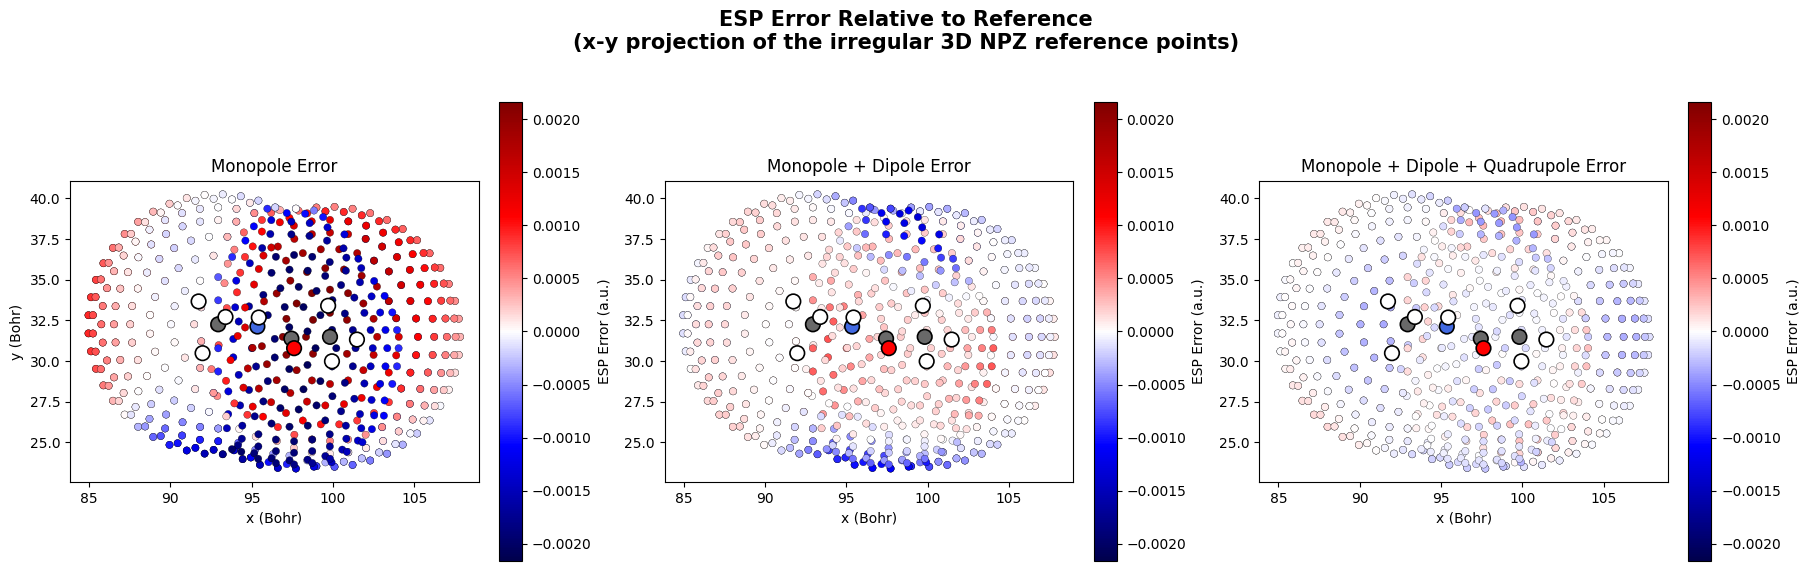

In [17]:
max_error = max(
    np.max(np.abs(error_mono)),
    np.max(np.abs(error_dipole)),
    np.max(np.abs(error_quad)),
)

print(f"Global max absolute error across all three panels: {max_error:.6e} a.u.")


def plot_error_panel(ax, error, title):
    """Draw one x-y-projected error scatter panel with a shared color scale."""
    sc = ax.scatter(
        reference_points[:, 0],
        reference_points[:, 1],
        c=error,
        cmap="seismic",
        vmin=-max_error,
        vmax=max_error,
        s=28,
        edgecolors="black",
        linewidths=0.2,
    )
    plot_atoms(ax, nb.atcoords, nb.atnums)

    ax.set_title(title)
    ax.set_xlabel("x (Bohr)")
    ax.set_aspect("equal")
    ax.grid(False)

    plt.colorbar(sc, ax=ax, shrink=0.85, label="ESP Error (a.u.)")
    return sc


fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
fig.suptitle(
    "ESP Error Relative to Reference\n"
    "(x-y projection of the irregular 3D NPZ reference points)",
    fontsize=15,
    fontweight="bold",
)

plot_error_panel(axes[0], error_mono, "Monopole Error")
plot_error_panel(axes[1], error_dipole, "Monopole + Dipole Error")
plot_error_panel(axes[2], error_quad, "Monopole + Dipole + Quadrupole Error")

axes[0].set_ylabel("y (Bohr)")

plt.savefig(OUTPUT_FIGURE_ERROR, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

## Conclusion

The FFprime MBIS multipole electrostatic potential was evaluated at the
742 exact reference coordinates supplied in `peptide-esp.npz`
(`2.5vdw_points`) and compared point-for-point against the corresponding
reference ESP (`2.5vdw_esp`).

Three successive levels were evaluated at those same reference points:

1. **Monopole** (`V_mono_reference`)
2. **Monopole + Dipole** (`V_dipole_reference`)
3. **Monopole + Dipole + Quadrupole** (`V_quad_reference`)

The **Validation Metrics** table above reports the RMSE, MAE, maximum
absolute error, and R^2 actually computed for each of the three models
against the reference ESP; those numbers — not an assumed trend — quantify
the agreement of each model with the reference ESP for this peptide.

**Figure 1** (`peptide_multipole_progression.png`) visualizes the spatial
structure of the potential itself at each level of the expansion, on the
separate, regular `grid_points` grid used for visualization only.

**Figure 2** (`peptide_multipole_error.png`) shows the signed ESP error at
each level, evaluated at the exact NPZ reference points and plotted with
one shared, zero-centered color scale across all three panels — so any
visible difference in color intensity between panels reflects a real
difference in error magnitude, and can be read directly off the figure
rather than assumed.

The effect of adding dipole and quadrupole terms for this peptide should
be interpreted from the actual RMSE/MAE/max-abs-error/R^2 values in the
table and the corresponding panels in Figures 1 and 2, rather than taken
for granted.